In [5]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import normalized_mutual_info_score as nmi
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering, AffinityPropagation, DBSCAN

# Import thuật toán FINCH từ thư viện finch-clust
from finch import FINCH

# Tạo tập dữ liệu giả lập (2000 mẫu, 5 cụm) để thử nghiệm nhanh
n_clusters_true = 5
X, y_true = make_blobs(n_samples=2000, centers=n_clusters_true, cluster_std=0.8, random_state=42)
print(f"Kích thước dữ liệu: {X.shape}")

Kích thước dữ liệu: (2000, 2)


In [6]:
# Khởi tạo các thuật toán cơ sở
algorithms = {
    "K-Means": KMeans(n_clusters=n_clusters_true, random_state=42, n_init=10),
    "Spectral": SpectralClustering(n_clusters=n_clusters_true, random_state=42, assign_labels='discretize'),
    "HAC (Ward)": AgglomerativeClustering(n_clusters=n_clusters_true, linkage='ward'),
    "AP": AffinityPropagation(random_state=42),
    "DBSCAN": DBSCAN(eps=0.5, min_samples=10) # DBSCAN cần tinh chỉnh tham số eps và min_samples
}

results = {}

print("Đang chạy các thuật toán cơ sở...")
for name, algo in algorithms.items():
    start_time = time.time()
    labels = algo.fit_predict(X)
    run_time = time.time() - start_time
    
    score = nmi(y_true, labels)
    results[name] = {'NMI': score, 'Time': run_time, 'Labels': labels}
    print(f"[{name}] Hoàn thành. NMI: {score:.4f} | Thời gian: {run_time:.4f}s")

Đang chạy các thuật toán cơ sở...
[K-Means] Hoàn thành. NMI: 0.9809 | Thời gian: 0.0283s
[Spectral] Hoàn thành. NMI: 0.9809 | Thời gian: 0.5865s
[HAC (Ward)] Hoàn thành. NMI: 0.9756 | Thời gian: 0.0790s
[AP] Hoàn thành. NMI: 0.4626 | Thời gian: 10.6669s
[DBSCAN] Hoàn thành. NMI: 0.8572 | Thời gian: 0.0153s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/cluster/_affinity_propagation.py:140: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(


In [7]:
print("\nĐang chạy thuật toán FINCH (không cần tham số)...")
start_time = time.time()

# FINCH trả về: 
# c: Các nhãn ở từng cấp độ phân cấp (hierarchy)
# num_clust: Số lượng cụm tương ứng ở mỗi cấp độ
# req_c: Nhãn nếu yêu cầu số cụm cụ thể
c, num_clust, req_c = FINCH(X)
run_time = time.time() - start_time

# Chọn phân vùng chi tiết nhất (cột đầu tiên của c) để đánh giá
finch_labels = c[:, 0]
score = nmi(y_true, finch_labels)

results["FINCH"] = {'NMI': score, 'Time': run_time, 'Labels': finch_labels}

print(f"[FINCH] Hoàn thành. NMI: {score:.4f} | Thời gian: {run_time:.4f}s | Số cụm tìm được (ở bước 1): {num_clust[0]}")


Đang chạy thuật toán FINCH (không cần tham số)...
[FINCH] Hoàn thành. NMI: 0.3996 | Thời gian: 0.0626s | Số cụm tìm được (ở bước 1): 622


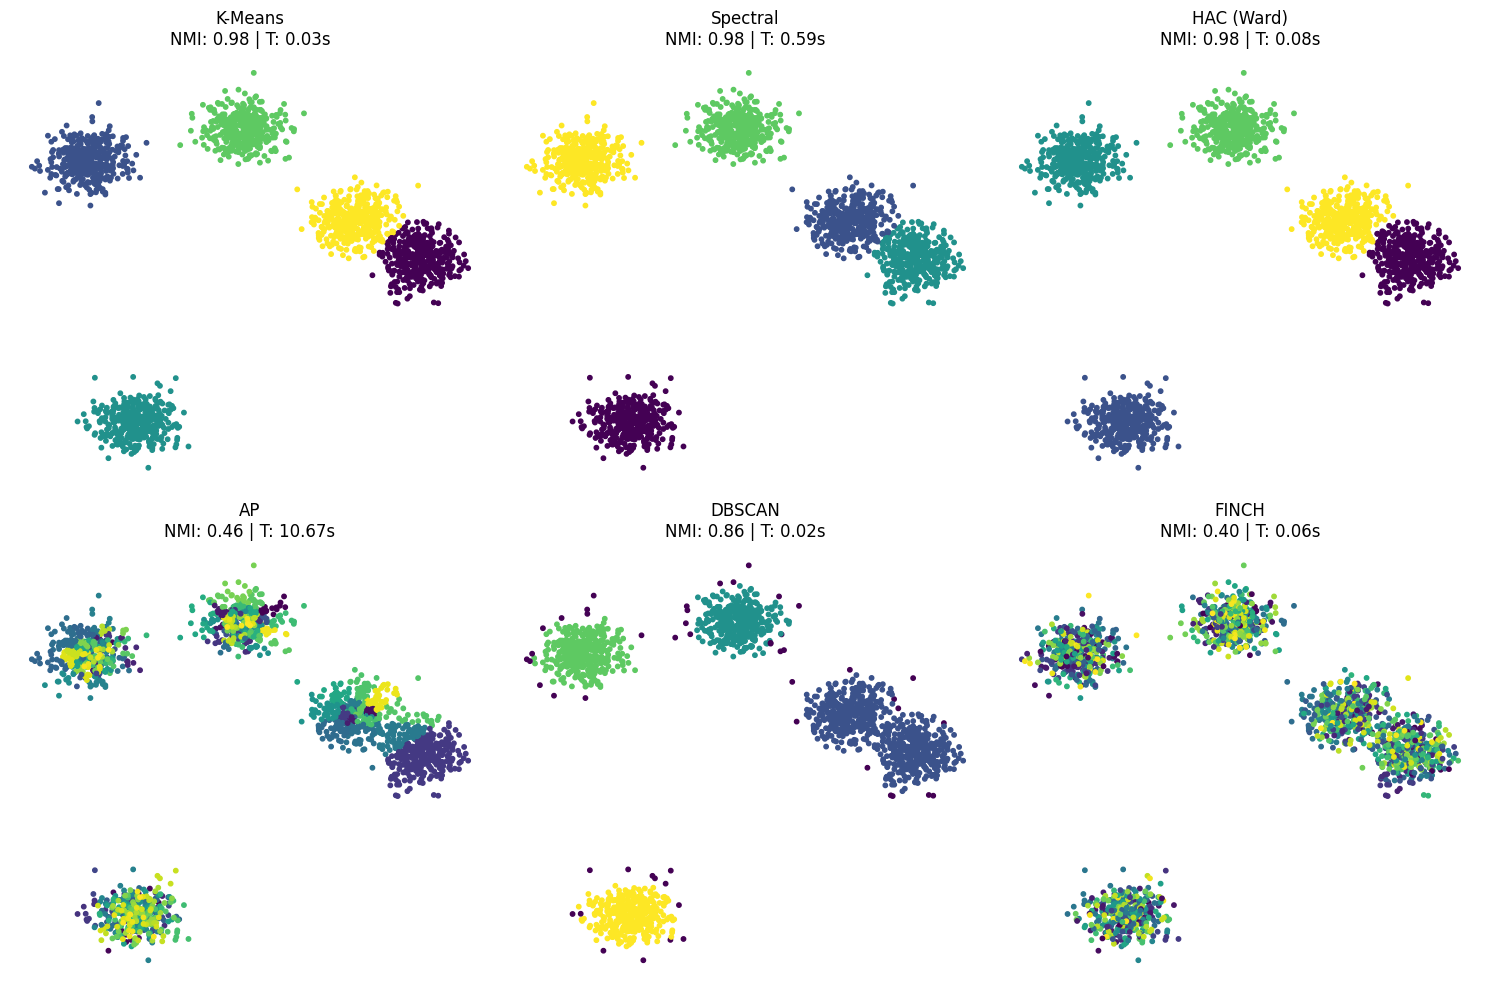

In [8]:
# Trực quan hóa kết quả
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, metrics) in enumerate(results.items()):
    ax = axes[i]
    ax.scatter(X[:, 0], X[:, 1], c=metrics['Labels'], cmap='viridis', s=10)
    ax.set_title(f"{name}\nNMI: {metrics['NMI']:.2f} | T: {metrics['Time']:.2f}s")
    ax.axis('off')

# Xóa các ô trống nếu có
for j in range(len(results), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()